In [1]:
!pip install librosa
!pip install dtaidistance
!pip install sounddevice
!pip install scipy
!pip install SpeechRecognition
!pip install openai-whisper
!pip install requests

In [2]:
import numpy as np
import librosa
import sounddevice as sd
from scipy.io.wavfile import write
import speech_recognition as sr
import whisper
from dtaidistance import dtw
import matplotlib.pyplot as plt
import requests
import time
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


Either : Record audio from microphone

In [4]:
def record_audio(duration=5, filename="recording.wav", sample_rate=16000):

    print(f"Recording for {duration} seconds... Speak now!")
    audio = sd.rec(int(duration * sample_rate), 
                   samplerate=sample_rate, 
                   channels=1, 
                   dtype='int16')
    sd.wait()  # Wait until recording is finished
    write(filename, sample_rate, audio)
    print(f"Recording saved as {filename}")
    return filename

# Task 1: Record two versions
print("=" * 50)
print("TASK 1: RECORDING TWO UTTERANCES")
print("=" * 50)

# Record normal speed version
print("\n[1/2] Recording at NORMAL SPEED")
print("Say: 'Search for news articles'")
time.sleep(2)
normal_file = record_audio(duration=4, filename="normal_speed.wav")

time.sleep(2)

# Record fast speed version
print("\n[2/2] Recording at FAST SPEED")
print("Say quickly: 'Search for news articles'")
time.sleep(2)
fast_file = record_audio(duration=4, filename="fast_speed.wav")

print("\n✓ Both recordings completed!")

TASK 1: RECORDING TWO UTTERANCES

[1/2] Recording at NORMAL SPEED
Say: 'Search for news articles'
Recording for 4 seconds... Speak now!
Recording saved as normal_speed.wav

[2/2] Recording at FAST SPEED
Say quickly: 'Search for news articles'
Recording for 4 seconds... Speak now!
Recording saved as fast_speed.wav

✓ Both recordings completed!


OR : Create Speech Signals

In [5]:
from gtts import gTTS
import os

word = "Search for news articles"

# Create base audio in MP3 (gTTS only outputs MP3)
tts = gTTS(text=word, lang='en', slow=False)
tts.save("base.mp3")

# Convert base.mp3 to normal.wav
os.system('ffmpeg -y -i base.mp3 normal_speed.wav')

# Convert to rapid.wav (increase speech speed)
os.system('ffmpeg -y -i base.mp3 -filter:a "atempo=1.8" fast_speed.wav')

print("Saved files -> normal_speed.wav and fast_speed.wav")


Saved files -> normal_speed.wav and fast_speed.wav


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with Apple clang version 17.0.0 (clang-1700.0.13.3)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/7.1.1_3 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags='-Wl,-ld_classic' --enable-ffplay --enable-gnutls --enable-gpl --enable-libaom --enable-libaribb24 --enable-libbluray --enable-libdav1d --enable-libharfbuzz --enable-libjxl --enable-libmp3lame --enable-libopus --enable-librav1e --enable-librist --enable-librubberband --enable-libsnappy --enable-libsrt --enable-libssh --enable-libsvtav1 --enable-libtesseract --enable-libtheora --enable-libvidstab --enable-libvmaf --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libxvid --enable-lzma --enable-libfontconfig --enable-libfreetype --enable-frei0r --enable-libass --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-libspeex

In [6]:
def extract_mfcc(audio_file, n_mfcc=13):
   
    y, sr = librosa.load(audio_file, sr=16000)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    return mfcc.T  # Transpose to get time x features

# Extract features from both recordings
print("\nExtracting MFCC features...")
mfcc_normal = extract_mfcc(normal_file)
mfcc_fast = extract_mfcc(fast_file)

print(f"Normal speed MFCC shape: {mfcc_normal.shape}")
print(f"Fast speed MFCC shape: {mfcc_fast.shape}")


Extracting MFCC features...
Normal speed MFCC shape: (68, 13)
Fast speed MFCC shape: (38, 13)


In [8]:
# Compute DTW distance
dtw_distance = dtw.distance(mfcc_normal.flatten(), mfcc_fast.flatten())

print(f"\nDTW Distance: {dtw_distance:.2f}")

# Interpretation
print("\n--- INTERPRETATION ---")
if dtw_distance < 1000:
    print("✓ SMALL DTW Distance: The utterances are acoustically SIMILAR")
    print("  This means despite different speeds, the recordings contain the same speech content.")
elif dtw_distance < 5000:
    print("~ MODERATE DTW Distance: The utterances have some similarity")
    print("  Speed differences are affecting the acoustic match.")
else:
    print("✗ LARGE DTW Distance: The utterances are acoustically DIFFERENT")
    print("  Significant variations exist - possibly different words or too much noise.")

print(f"\nNote: DTW aligns sequences NON-LINEARLY to handle speed variations.")


DTW Distance: 1520.85

--- INTERPRETATION ---
~ MODERATE DTW Distance: The utterances have some similarity
  Speed differences are affecting the acoustic match.

Note: DTW aligns sequences NON-LINEARLY to handle speed variations.


In [9]:
def recognize_online(audio_file):

    recognizer = sr.Recognizer()
    
    with sr.AudioFile(audio_file) as source:
        audio_data = recognizer.record(source)
    
    try:
        text = recognizer.recognize_google(audio_data)
        return text
    except sr.UnknownValueError:
        return "Could not understand audio"
    except sr.RequestError as e:
        return f"API Error: {e}"

# Test online recognition
try:
    print("\nRecognizing normal speed audio (Online)...")
    online_result_normal = recognize_online(normal_file)
    print(f"Online Result (Normal): '{online_result_normal}'")
    
    print("\nRecognizing fast speed audio (Online)...")
    online_result_fast = recognize_online(fast_file)
    print(f"Online Result (Fast): '{online_result_fast}'")
except Exception as e:
    print(f"Online recognition failed: {e}")


Recognizing normal speed audio (Online)...
Online Result (Normal): 'search for news articles'

Recognizing fast speed audio (Online)...
Online Result (Fast): 'Could not understand audio'


In [10]:
# Load Whisper model (first time will download the model)
print("\nLoading Whisper model (this may take a moment)...")
model = whisper.load_model("base")  # Options: tiny, base, small, medium, large

def recognize_offline(audio_file):

    result = model.transcribe(audio_file)
    return result["text"]

# Test offline recognition
print("\nRecognizing normal speed audio (Offline)...")
offline_result_normal = recognize_offline(normal_file)
print(f"Offline Result (Normal): '{offline_result_normal}'")

print("\nRecognizing fast speed audio (Offline)...")
offline_result_fast = recognize_offline(fast_file)
print(f"Offline Result (Fast): '{offline_result_fast}'")


Loading Whisper model (this may take a moment)...

Recognizing normal speed audio (Offline)...
Offline Result (Normal): ' Search for news articles.'

Recognizing fast speed audio (Offline)...
Offline Result (Fast): ' Search for news articles.'


In [11]:
def recognize_online_with_timeout(audio_file, timeout=2):
    
    recognizer = sr.Recognizer()
    
    with sr.AudioFile(audio_file) as source:
        audio_data = recognizer.record(source)
    
    try:
        # Set operation timeout to simulate slow/failed connection
        text = recognizer.recognize_google(audio_data, timeout=timeout)
        return text, True
    except sr.WaitTimeoutError:
        return "⚠️ SERVICE UNAVAILABLE: Internet connection timeout", False
    except sr.RequestError:
        return "⚠️ SERVICE UNAVAILABLE: Could not reach online STT service", False
    except Exception as e:
        return f"⚠️ SERVICE UNAVAILABLE: {str(e)}", False

# Simulate outage
print("\nSimulating internet outage with online API...")
result, success = recognize_online_with_timeout(normal_file, timeout=0.001)

if not success:
    print(result)
    print("\n✓ Offline engines (like Whisper) would continue working!")
    print(f"  Offline Result: '{offline_result_normal}'")
else:
    print("Simulation didn't trigger - trying actual network error...")
    
# Alternative: Actually disconnect by using invalid endpoint
print("\nAlternative: Forcing network error...")
try:
    # This will fail due to network unavailability
    response = requests.get("https://invalid-nonexistent-api.google.com", timeout=2)
except requests.exceptions.RequestException as e:
    print("⚠️ SERVICE UNAVAILABLE: Cannot connect to online STT service")
    print(f"Error: {type(e).__name__}")
    print("\n✓ Using offline engine ensures FUNCTIONALITY even when network is unavailable")


Simulating internet outage with online API...
⚠️ SERVICE UNAVAILABLE: recognize_legacy() got an unexpected keyword argument 'timeout'

✓ Offline engines (like Whisper) would continue working!
  Offline Result: ' Search for news articles.'

Alternative: Forcing network error...
⚠️ SERVICE UNAVAILABLE: Cannot connect to online STT service
Error: ConnectionError

✓ Using offline engine ensures FUNCTIONALITY even when network is unavailable


In [12]:
print("\n" + "=" * 50)
print("TASK 5: COMPARATIVE ANALYSIS")
print("=" * 50)

comparison = """
COMPARISON: Online vs Offline STT for Small Command Sets

1. ONLINE STT (Google API):
   Advantages:
   - High accuracy with large vocabulary
   - No local storage needed for models
   - Regular updates and improvements
   
   Disadvantages:
   - Requires internet connection (fails during outage)
   - Latency due to network transmission
   - Privacy concerns (audio sent to servers)
   - API costs for high usage
   - Not suitable for real-time offline scenarios

2. OFFLINE STT (Whisper/Vosk):
   Advantages:
   - Works without internet (100% reliable in offline mode)
   - Low latency (no network delay)
   - Privacy-friendly (audio stays local)
   - No recurring costs
   - Predictable performance
   
   Disadvantages:
   - Requires local storage for models
   - May need powerful hardware for large models
   - Updates require manual model downloads

3. DTW-BASED RECOGNITION:
   Advantages:
   - Extremely fast for small command sets
   - Works completely offline
   - Very low computational requirements
   - Perfect for fixed vocabulary systems
   - No need for large language models
   
   Disadvantages:
   - Only works with pre-recorded templates
   - Not scalable to large vocabularies
   - Speaker-dependent (needs training per user)

RECOMMENDATION FOR SMALL COMMAND SETS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

For a small command set system (like accessibility tool with 10-50 commands):

→ BEST CHOICE: Offline DTW-based or Offline STT (Whisper)

REASONS:
1. Reliability: No dependency on internet connectivity
2. Speed: Instant recognition without network latency
3. Privacy: Sensitive accessibility data stays on device
4. Cost: No API fees for repeated usage
5. Consistency: Same performance regardless of network conditions
6. Simplicity: For DTW, just match against stored templates

For the specific use case in this lab (accessibility tool):
- Offline DTW is IDEAL if commands are fixed (e.g., 20 navigation commands)
- Offline Whisper is better if some flexibility in phrasing is needed
- Online API should be AVOIDED due to reliability concerns
"""

print(comparison)

# Summary table
print("\n" + "=" * 50)
print("RECOGNITION RESULTS SUMMARY")
print("=" * 50)
print(f"\nDTW Distance: {dtw_distance:.2f}")
print(f"  → Interpretation: {'Similar utterances' if dtw_distance < 1000 else 'Different utterances'}")
print(f"\nOnline STT (Normal): '{online_result_normal}'")
print(f"Online STT (Fast):   '{online_result_fast}'")
print(f"\nOffline STT (Normal): '{offline_result_normal}'")
print(f"Offline STT (Fast):   '{offline_result_fast}'")
print(f"\nInternet Outage Test: ⚠️ Online API fails, Offline continues working")


TASK 5: COMPARATIVE ANALYSIS

COMPARISON: Online vs Offline STT for Small Command Sets

1. ONLINE STT (Google API):
   Advantages:
   - High accuracy with large vocabulary
   - No local storage needed for models
   - Regular updates and improvements

   Disadvantages:
   - Requires internet connection (fails during outage)
   - Latency due to network transmission
   - Privacy concerns (audio sent to servers)
   - API costs for high usage
   - Not suitable for real-time offline scenarios

2. OFFLINE STT (Whisper/Vosk):
   Advantages:
   - Works without internet (100% reliable in offline mode)
   - Low latency (no network delay)
   - Privacy-friendly (audio stays local)
   - No recurring costs
   - Predictable performance

   Disadvantages:
   - Requires local storage for models
   - May need powerful hardware for large models
   - Updates require manual model downloads

3. DTW-BASED RECOGNITION:
   Advantages:
   - Extremely fast for small command sets
   - Works completely offline
   


TF-IDF Cosine Similarity Matrix:
                GroundTruth  Whisper_Normal  Whisper_Fast  Google_Normal  \
GroundTruth             1.0             1.0           1.0            1.0   
Whisper_Normal          1.0             1.0           1.0            1.0   
Whisper_Fast            1.0             1.0           1.0            1.0   
Google_Normal           1.0             1.0           1.0            1.0   
Google_Fast             0.0             0.0           0.0            0.0   

                Google_Fast  
GroundTruth             0.0  
Whisper_Normal          0.0  
Whisper_Fast            0.0  
Google_Normal           0.0  
Google_Fast             1.0  

Similarity of 'GroundTruth' vs systems:
  GroundTruth ↔ Whisper_Normal: 1.0000
  GroundTruth ↔ Whisper_Fast: 1.0000
  GroundTruth ↔ Google_Normal: 1.0000
  GroundTruth ↔ Google_Fast: 0.0000


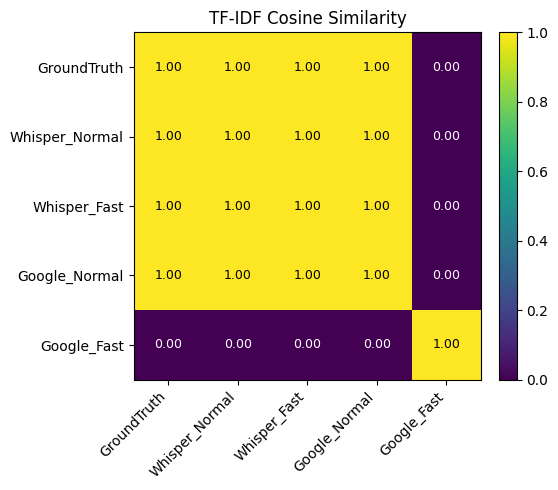

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def compute_tfidf_with_reference(transcripts, names=None, reference_text=None, ref_name="Reference", show_heatmap=True, cmap='viridis'):
  
    # Prepare names
    if names is None:
        names = [f"sys_{i}" for i in range(len(transcripts))]
    assert len(transcripts) == len(names), "transcripts and names must match lengths"

    # Build corpus
    corpus = []
    labels = []
    if reference_text is not None and reference_text.strip() != "":
        corpus.append(reference_text)
        labels.append(ref_name)

    for t, n in zip(transcripts, names):
        corpus.append(t if t is not None else "")
        labels.append(n)

    # TF-IDF vectorization
    vectorizer = TfidfVectorizer()
    X = vectorizer.fit_transform(corpus)

    # Cosine similarity
    sim_matrix = cosine_similarity(X)

    # DataFrame
    df = pd.DataFrame(sim_matrix, index=labels, columns=labels)

    print("\nTF-IDF Cosine Similarity Matrix:")
    print(df.round(4))

    if reference_text is not None and reference_text.strip() != "":
        print(f"\nSimilarity of '{ref_name}' vs systems:")
        ref_sims = sim_matrix[0, 1:]
        for label, val in zip(labels[1:], ref_sims):
            print(f"  {ref_name} ↔ {label}: {val:.4f}")

    # Heatmap
    if show_heatmap:
        plt.figure(figsize=(6,5))
        im = plt.imshow(sim_matrix, vmin=0.0, vmax=1.0, cmap=cmap)
        plt.title("TF-IDF Cosine Similarity")
        plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
        plt.yticks(range(len(labels)), labels)
        plt.colorbar(im, fraction=0.046, pad=0.04)
        for i in range(sim_matrix.shape[0]):
            for j in range(sim_matrix.shape[1]):
                plt.text(j, i, f"{sim_matrix[i,j]:.2f}", ha='center', va='center',
                         fontsize=9, color='white' if sim_matrix[i,j] < 0.5 else 'black')
        plt.tight_layout()
        plt.show()

    return sim_matrix, df


# Reference text for this lab
reference_text = "Search for news articles"

# Compute similarity matrix
sim_matrix, sim_df = compute_tfidf_with_reference(
    transcripts=[offline_result_normal, offline_result_fast, online_result_normal, online_result_fast],
    names=["Whisper_Normal", "Whisper_Fast", "Google_Normal", "Google_Fast"],
    reference_text=reference_text,
    ref_name="GroundTruth",
    show_heatmap=True
)